#  Generating Synthetic Galaxies with Conditional DDPMs

Welcome to this tutorial on Denoising Diffusion Probabilistic Models (DDPMs). Today, we will train a generative model to create highly realistic, synthetic galaxy images from scratch, conditioned on their morphological class (e.g., edge-on disks, smooth ellipticals).

### Environment Installation

#### Run this in the terminal of your new server to ensure all dependencies, including the HDF5 reader for the dataset, are ready.

#### <span style="color:orange">*pip install torch torchvision diffusers accelerate h5py matplotlib tqdm jupyter notebook*</font>


### The Core Math: The Forward Process

Diffusion models are built on two processes. The first is the Forward Process (or diffusion process), where we gradually add Gaussian noise to a clean image over $T$ timesteps according to a variance schedule $\beta_t$.

The transition from one step to the next is defined as: 
$$q(x_t | x_{t-1}) = \mathcal{N}(x_t; \sqrt{1 - \beta_t} x_{t-1}, \beta_t \mathbf{I})$$

Instead of applying this $t$ times iteratively, we use a closed-form shortcut to jump straight to any arbitrary timestep $t$. Let $\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$. We can sample the noisy image $x_t$ directly from the clean image $x_0$ and pure noise $\epsilon \sim \mathcal{N}(0, \mathbf{I})$:
$$x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon$$


### Imports and Device Setup

In [14]:
import torch
import torch.nn.functional as F
import h5py
import numpy as np
import os
import urllib.request
import matplotlib.pyplot as plt
import torchvision.utils as vutils
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from diffusers import UNet2DModel, DDPMScheduler
from tqdm.auto import tqdm

# Universal device selection (CUDA for the server/Colab, MPS for your Mac)
def get_device():
    if torch.cuda.is_available(): return "cuda"
    elif torch.backends.mps.is_available(): return "mps"
    else: return "cpu"

device = get_device()
print(f"Using device: {device}")

Using device: cuda


### Preparing the Astronomical Data

To train our model, we use the Galaxy10 SDSS dataset. We will crop these images to $64 \times 64$ pixels (U-Nets perform best with base-2 dimensions) and normalize the pixel values to the $[-1, 1]$ range. This normalization is critical because it matches the standard normal distribution $\mathcal{N}(0, 1)$ of the Gaussian noise we will be adding to them.

(g, r and i band)


In [15]:
class Galaxy10SDSS(Dataset):
    """Downloads and loads the Galaxy10 SDSS Dataset (~200MB)."""
    def __init__(self, root, download=True, transform=None):
        self.root = root
        self.transform = transform
        self.filepath = os.path.join(self.root, "Galaxy10.h5")
        self.url = "https://zenodo.org/records/10844811/files/Galaxy10.h5"
        
        if download: self._download()
        if not os.path.exists(self.filepath):
            raise RuntimeError("Dataset not found.")

        with h5py.File(self.filepath, 'r') as F:
            self.images = np.array(F['images'])
            self.labels = np.array(F['ans'])

    def _download(self):
        if os.path.exists(self.filepath): return
        os.makedirs(self.root, exist_ok=True)
        print("Downloading Galaxy10 SDSS (200MB)...")
        urllib.request.urlretrieve(self.url, self.filepath)
        print("Download complete.")

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx])
        label = self.labels[idx]
        if self.transform: img = self.transform(img)
        return img, label

# Transforms: Resize to 64x64 and normalize to [-1, 1] for DDPM
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
])

dataset = Galaxy10SDSS(root='./data', download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, drop_last=True)
print(f"Loaded {len(dataset)} galaxies.")

Loaded 21785 galaxies.


### Defining the Model and The Objective

Now we define our Reverse Process. If we know how to reverse the noise $q(x_{t-1} | x_t)$, we can start with pure static noise and walk backward to generate a clean galaxy.

Since the exact reverse distribution is intractable, we use a Neural Network (a U-Net), denoted as $\epsilon_\theta$, to approximate it. The U-Net's job is to look at a noisy image $x_t$ at timestep $t$ and predict the exact noise $\epsilon$ that was added to it.

### The Conditional Training Objective

Because we want to control the galaxy type, we inject the morphological class label $c$ into the network. Our training objective is to minimize the Mean Squared Error (MSE) between the true noise $\epsilon$ and our network's prediction:
$$\mathcal{L} = \mathbb{E}_{t, x_0, \epsilon} \left[ || \epsilon - \epsilon_\theta(x_t, t, c) ||^2 \right]$$



In [16]:
# 1. The Noise Scheduler
noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000, 
    beta_schedule="linear",
    prediction_type="epsilon"
)

# 2. The Conditional U-Net
model = UNet2DModel(
    sample_size=64,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 256, 256),
    down_block_types=("DownBlock2D", "DownBlock2D", "AttnDownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
    num_class_embeds=10  # Crucial for conditional generation
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)


### The Conditional DDPM Architecture
Here is how our data flows through the DDPM. 
1. **Forward Process:** We systematically destroy a clean galaxy ($x_0$) into pure noise ($x_T$).
2. **Reverse Process:** Our U-Net learns to predict the noise at step $t$, guided by the morphology class label $c$.



### The Interactive "Hands-On" Workflow

In [17]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import torch

# Grab one real galaxy from our dataset to destroy
clean_batch, labels_batch = next(iter(dataloader))
demo_img = clean_batch[0].to(device)
demo_label = labels_batch[0].item()

def interactive_forward_process(t):
    """Dynamically applies DDPM forward math based on the slider value."""
    if t == 0:
        noisy_img = demo_img
    else:
        # 1. Generate pure noise
        noise = torch.randn_like(demo_img)
        # 2. Define the timestep as a tensor
        t_tensor = torch.tensor([t], device=device).long()
        # 3. Apply the closed-form forward equation: sqrt(alpha_bar)*x_0 + sqrt(1-alpha_bar)*noise
        noisy_img = noise_scheduler.add_noise(demo_img.unsqueeze(0), noise.unsqueeze(0), t_tensor)[0]
        
    # Format the tensor for Matplotlib (Un-normalize from [-1, 1] to [0, 1])
    img_np = (noisy_img.cpu().permute(1, 2, 0).numpy() + 1) / 2
    img_np = np.clip(img_np, 0, 1)
    
    # Plotting
    plt.figure(figsize=(6, 6))
    plt.imshow(img_np)
    plt.title(f"Forward Process\nTimestep: {t}/1000 | Target Class: {demo_label}", fontsize=14, pad=15)
    plt.axis('off')
    plt.show()

# Create a sleek interactive slider
slider = widgets.IntSlider(
    min=0, max=999, step=10, value=0, 
    description='Timestep (t):', 
    layout=widgets.Layout(width='600px')
)

print("Slide the bar to add Gaussian noise according to our variance schedule:")
widgets.interact(interactive_forward_process, t=slider)

Slide the bar to add Gaussian noise according to our variance schedule:


interactive(children=(IntSlider(value=0, description='Timestep (t):', layout=Layout(width='600px'), max=999, s…

<function __main__.interactive_forward_process(t)>

### The Conditional Training Loop

In our training loop, you will see the math come to life. For each batch, we:

1. Sample a random timestep $t$.
2. Generate true noise $\epsilon$.
3. Corrupt $x_0$ to $x_t$ using the scheduler's add_noise function (which applies the $\sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon$ equation).
4. Ask the model to predict the noise, passing in $x_t$, $t$, and the class label $c$.
5. Compute the MSE loss and backpropagate.



In [18]:
import os

EPOCHS = 1 # Set this to your target total epochs
checkpoint_path = "conditional_ddpm_galaxy10.pth"

# === 1. CHECKPOINT LOADING LOGIC ===
if os.path.exists(checkpoint_path):
    print(f"🔄 Found existing checkpoint at '{checkpoint_path}'. Loading...")
    # Load the weights into the model
    model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
    print("✅ Model loaded! Resuming training...")
else:
    print("✨ No checkpoint found. Starting training from scratch.")

# === 2. TRAINING LOOP ===
print(f"Starting Conditional Training on {device}...")

for epoch in range(EPOCHS):
    model.train()
    progress_bar = tqdm(total=len(dataloader), desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for clean_images, labels in dataloader:
        clean_images = clean_images.to(device)
        labels = labels.to(device, dtype=torch.long) # Cast to 64-bit int
        
        # Sample noise and timesteps
        noise = torch.randn_like(clean_images).to(device)
        bs = clean_images.shape[0]
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bs,), device=device).long()
        
        # Forward diffusion
        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)
        
        # Predict noise (Conditioned on labels)
        noise_pred = model(noisy_images, timesteps, class_labels=labels).sample
        
        # Loss and Backprop
        loss = F.mse_loss(noise_pred, noise)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        progress_bar.update(1)
        progress_bar.set_postfix({"Loss": loss.item()})
        
    progress_bar.close()
        
    # === 3. SAVE AFTER EVERY EPOCH ===
    # This ensures you don't lose your work if the server job is killed
    torch.save(model.state_dict(), checkpoint_path)
    print(f"💾 Checkpoint saved to {checkpoint_path} after Epoch {epoch+1}")

print("🎉 Training fully complete!")

🔄 Found existing checkpoint at 'conditional_ddpm_galaxy10.pth'. Loading...
✅ Model loaded! Resuming training...
Starting Conditional Training on cuda...


Epoch 1/1:   0%|          | 0/340 [00:00<?, ?it/s]

💾 Checkpoint saved to conditional_ddpm_galaxy10.pth after Epoch 1
🎉 Training fully complete!


### Inference & The Reverse Math

With a trained model, we can generate new data. We start by sampling pure noise $x_T \sim \mathcal{N}(0, \mathbf{I})$ and provide the specific class label $c$ we want.

We then iteratively apply the Reverse Sampling Equation for $t = T, \dots, 1$:
$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{1-\alpha_t}{\sqrt{1-\bar{\alpha}_t}} \epsilon_\theta(x_t, t, c) \right) + \sigma_t z$$
where $z \sim \mathcal{N}(0, \mathbf{I})$ if $t > 1$, else $0$.

The diffusers scheduler abstracts this complex algebraic step into a simple call: noise_scheduler.step().

#### 
The "Face-On" Disks (Viewing the galaxy from above)

Class 0: Disk, Face-on, No Spiral (It looks like a flat pancake with no discernible arms).

Class 7: Disk, Face-on, Tight Spiral (The spiral arms are tightly wound around the core).

Class 8: Disk, Face-on, Medium Spiral

Class 9: Disk, Face-on, Loose Spiral (The arms are wide, sweeping, and separated).

The "Smooth" Galaxies (Ellipticals)

Class 1: Smooth, Completely round (A perfect sphere of stars).

Class 2: Smooth, In-between round (Slightly oval).

Class 3: Smooth, Cigar shaped (Highly elongated elliptical).

The "Edge-On" Disks (Viewing the galaxy from the side)

Class 4: Disk, Edge-on, Rounded Bulge (Looks like a thin line with a distinct spherical glowing core in the middle).

Class 5: Disk, Edge-on, Boxy Bulge (The central core looks rectangular/boxy rather than spherical).

Class 6: Disk, Edge-on, No Bulge (Just a flat, thin line of dust and stars).

Loading pre-trained model from 'conditional_ddpm_galaxy10.pth'...
✅ Model ready for inference!
Generating Class 4 galaxies...


Denoising:   0%|          | 0/1000 [00:00<?, ?it/s]

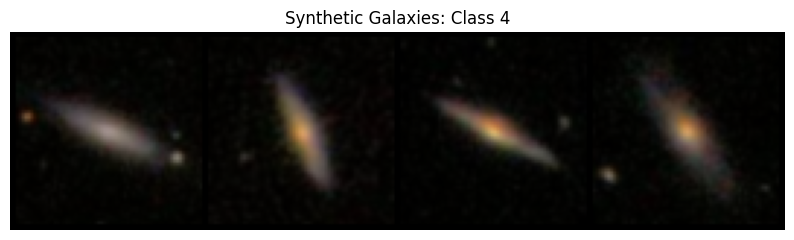

Generating Class 2 galaxies...


Denoising:   0%|          | 0/1000 [00:00<?, ?it/s]

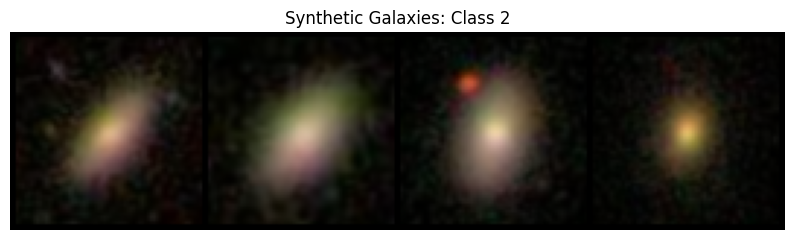

Generating Class 7 galaxies...


Denoising:   0%|          | 0/1000 [00:00<?, ?it/s]

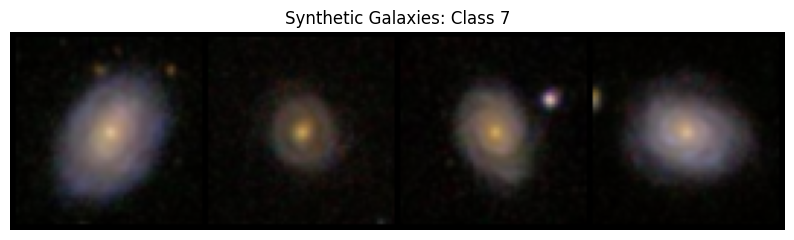

Generating Class 9 galaxies...


Denoising:   0%|          | 0/1000 [00:00<?, ?it/s]

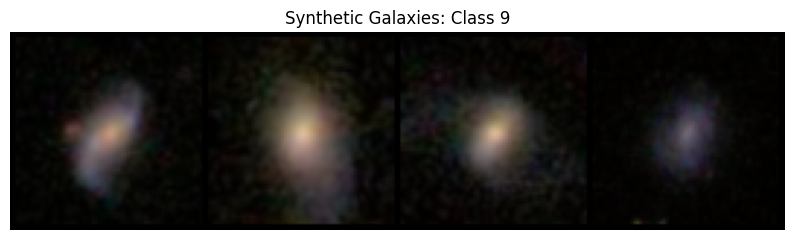

In [19]:

import os

checkpoint_path = "conditional_ddpm_galaxy10.pth"

# === 1. LOAD PRE-TRAINED WEIGHTS ===
if os.path.exists(checkpoint_path):
    print(f"Loading pre-trained model from '{checkpoint_path}'...")
    model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
    print("✅ Model ready for inference!")
else:
    print(f"⚠️ Warning: '{checkpoint_path}' not found.")
    print("Using untrained model (images will look like random noise).")

# === 2. SAMPLING FUNCTION ===
def generate_specific_galaxy(target_class_idx, num_images=4):
    print(f"Generating Class {target_class_idx} galaxies...")
    
    # Set model to evaluation mode (turns off dropout, etc.)
    model.eval()
    
    # Create the label tensor (Make sure it's torch.long!)
    labels = torch.tensor([target_class_idx] * num_images, dtype=torch.long, device=device)
    
    # Start with pure random noise
    x = torch.randn(num_images, 3, 64, 64).to(device)
    
    # Reverse diffusion process
    for t in tqdm(noise_scheduler.timesteps, desc="Denoising"):
        with torch.no_grad():
            model_output = model(x, t, class_labels=labels).sample
        x = noise_scheduler.step(model_output, t, x).prev_sample
        
    # Un-normalize [-1, 1] back to [0, 1] and format for display
    x = (x + 1) / 2
    grid = vutils.make_grid(x, nrow=num_images, padding=2, normalize=False)
    
    # Plotting
    plt.figure(figsize=(10, 4))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.axis('off')
    plt.title(f"Synthetic Galaxies: Class {target_class_idx}")
    
    # If testing via terminal/batch job, use savefig instead of show!
    # plt.savefig(f"generated_class_{target_class_idx}.png", bbox_inches='tight')
    plt.show() 

# === 3. DEMO ===
# Class 4: Disk, Edge-on, Rounded Bulge
generate_specific_galaxy(4)

# Class 2: Smooth, In-between round
generate_specific_galaxy(2)

# Class 7: Disk, Face-on, Tight Spiral
generate_specific_galaxy(7)

# Class 9: Disk, Face-on, Loose Spiral
generate_specific_galaxy(9)

## Accelerating Inference (Theory)

Our standard DDPM model generates beautiful galaxies, but it is slow. It requires 1000 sequential passes through the U-Net. This is because standard DDPM relies on a Markov chain approximation (a Stochastic Differential Equation, or SDE), which demands tiny step sizes to remain mathematically valid.

To accelerate this, we can change the Scheduler without retraining the U-Net.

### 1. DDIM (Denoising Diffusion Implicit Models)
DDIM generalizes the DDPM process to be non-Markovian. It converts the stochastic reverse process into a deterministic Ordinary Differential Equation (ODE). Because it is deterministic, we can "skip" steps, evaluating the model only 50 times instead of 1000.

The DDIM update step bypasses the random noise injection ($\sigma_t = 0$), directly pointing toward the predicted $x_0$:
$$x_{t-\Delta t} = \sqrt{\alpha_{t-\Delta t}} \underbrace{\left( \frac{x_t - \sqrt{1-\alpha_t}\epsilon_\theta(x_t)}{\sqrt{\alpha_t}} \right)}_{\text{Predicted Clean Image } x_0} + \sqrt{1-\alpha_{t-\Delta t}}\epsilon_\theta(x_t)$$


### 2. DPM-Solver (Advanced ODE Solvers)
Once we frame diffusion as an ODE (the "Probability Flow ODE"), we can use advanced numerical methods (like Runge-Kutta solvers tailored specifically for diffusion) to solve the equation even faster. DPM-Solver++ can converge on a high-quality image in as few as 15 to 20 steps.

Let's implement these three mathematical approaches, give them the exact same starting noise, and compare their speeds and outputs!


#### Performance Comparison (DDPM vs DDIM vs DPM-Solver)

Running baseline DDPM (1000 steps)...
Running DDIM ODE (50 steps)...
Running DPM-Solver++ ODE (20 steps)...


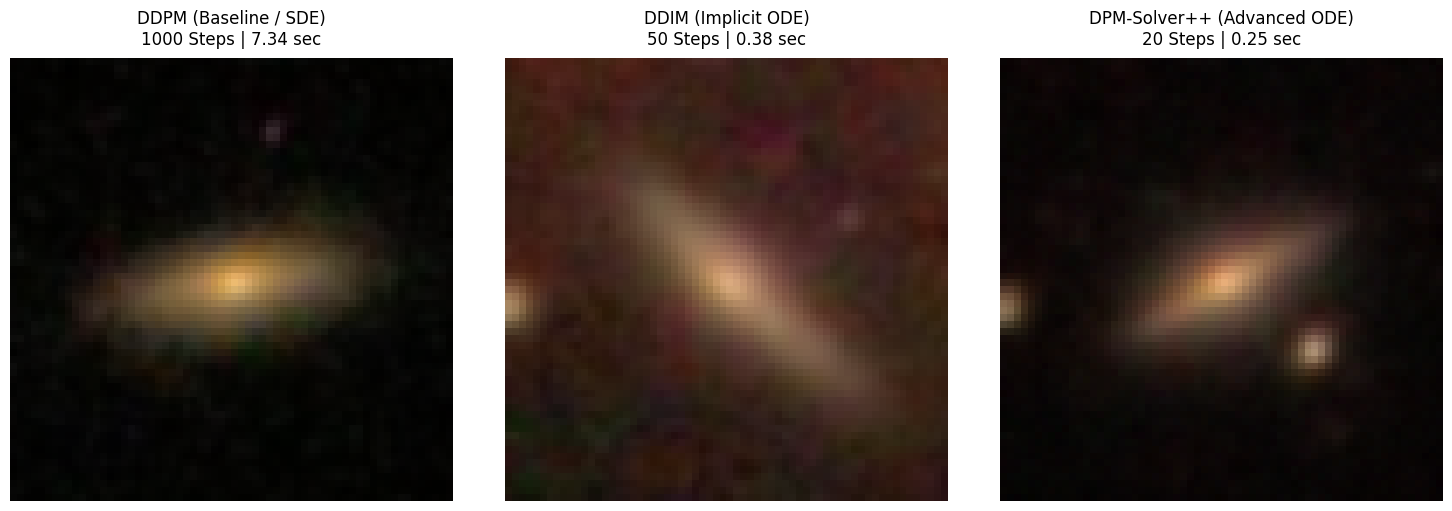

🚀 DPM-Solver++ is 29.9x faster than standard DDPM!


In [20]:
import time
from diffusers import DDIMScheduler, DPMSolverMultistepScheduler

# --- 1. Initialize our Accelerated Schedulers ---
# DDIM: Deterministic, skips steps (ODE formulation)
ddim_scheduler = DDIMScheduler(
    num_train_timesteps=1000,
    beta_schedule="linear",
    prediction_type="epsilon"
)

# DPM-Solver++: High-order numerical ODE solver
dpm_scheduler = DPMSolverMultistepScheduler(
    num_train_timesteps=1000,
    beta_schedule="linear",
    prediction_type="epsilon",
    solver_order=2,
    algorithm_type="dpmsolver++"
)

# --- 2. Universal Sampling Function ---
def sample_with_scheduler(scheduler, num_steps, target_class_idx, seed=42):
    """Generates an image using a specific scheduler and step count."""
    
    # Configure the scheduler to skip steps
    scheduler.set_timesteps(num_steps)
    
    # 1. Ensure we start with the EXACT SAME NOISE for a fair comparison
    torch.manual_seed(seed)
    x = torch.randn(1, 3, 64, 64).to(device)
    labels = torch.tensor([target_class_idx], dtype=torch.long, device=device)
    
    # 2. Timing the reverse loop
    start_time = time.time()
    
    for t in scheduler.timesteps:
        with torch.no_grad():
            model_output = model(x, t, class_labels=labels).sample
        x = scheduler.step(model_output, t, x).prev_sample
        
    elapsed_time = time.time() - start_time
    
    # Un-normalize for display
    x = (x + 1) / 2 
    return x[0].cpu().permute(1, 2, 0).numpy(), elapsed_time

# --- 3. Run the Comparison ---
## class 4 Disk, Edge-on, Rounded Bulge 
target_class = 4
fixed_seed = 1024 # Keeps the initial noise identical for all 3 runs

print("Running baseline DDPM (1000 steps)...")
img_ddpm, time_ddpm = sample_with_scheduler(noise_scheduler, num_steps=1000, target_class_idx=target_class, seed=fixed_seed)

print("Running DDIM ODE (50 steps)...")
img_ddim, time_ddim = sample_with_scheduler(ddim_scheduler, num_steps=50, target_class_idx=target_class, seed=fixed_seed)

print("Running DPM-Solver++ ODE (20 steps)...")
img_dpm, time_dpm = sample_with_scheduler(dpm_scheduler, num_steps=20, target_class_idx=target_class, seed=fixed_seed)

# --- 4. Plotting the Results Side-by-Side ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def plot_result(ax, img, time_taken, title, steps):
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title(f"{title}\n{steps} Steps | {time_taken:.2f} sec", fontsize=12, pad=10)
    ax.axis('off')

plot_result(axes[0], img_ddpm, time_ddpm, "DDPM (Baseline / SDE)", 1000)
plot_result(axes[1], img_ddim, time_ddim, "DDIM (Implicit ODE)", 50)
plot_result(axes[2], img_dpm, time_dpm, "DPM-Solver++ (Advanced ODE)", 20)

plt.tight_layout()
plt.show()

# Print Speedup
speedup = time_ddpm / time_dpm
print(f"🚀 DPM-Solver++ is {speedup:.1f}x faster than standard DDPM!")

### Accelerating Inference - ODEs vs. SDEs
Our standard DDPM model generates beautiful galaxies, but it requires 1000 sequential passes through the U-Net. To accelerate this, we can swap out the mathematical Scheduler without retraining the model.


### 1. DPM-Solver++ (The ODE Approach)

By framing the reverse diffusion process as a deterministic Ordinary Differential Equation (ODE), we can use advanced numerical methods (like Runge-Kutta) to take massive shortcuts. DPM-Solver++ can generate an image in just 20 steps. However, because it is purely deterministic, it can sometimes smooth over fine textures.

### 2. DPM-Solver++ SDE (The Stochastic Approach)

To recover lost detail, we introduce a Stochastic Differential Equation (SDE) variant. It still skips steps to maintain speed, but it intentionally injects a calculated amount of random noise $z \sim \mathcal{N}(0, \mathbf{I})$ at each jump:$$x_{t-\Delta t} = \text{Deterministic\_Update}(x_t) + \sigma_t z$$

This stochastic "shake" prevents the image from becoming overly smooth, preserving the granular, high-frequency details essential for realistic astronomical data (like star-forming regions and dust lanes).

Let's race them! We will give all three the exact same starting noise and compare the results.

Running baseline DDPM (1000 steps)...
Running DPM-Solver++ ODE (20 steps)...
Running DPM-Solver++ SDE (20 steps)...


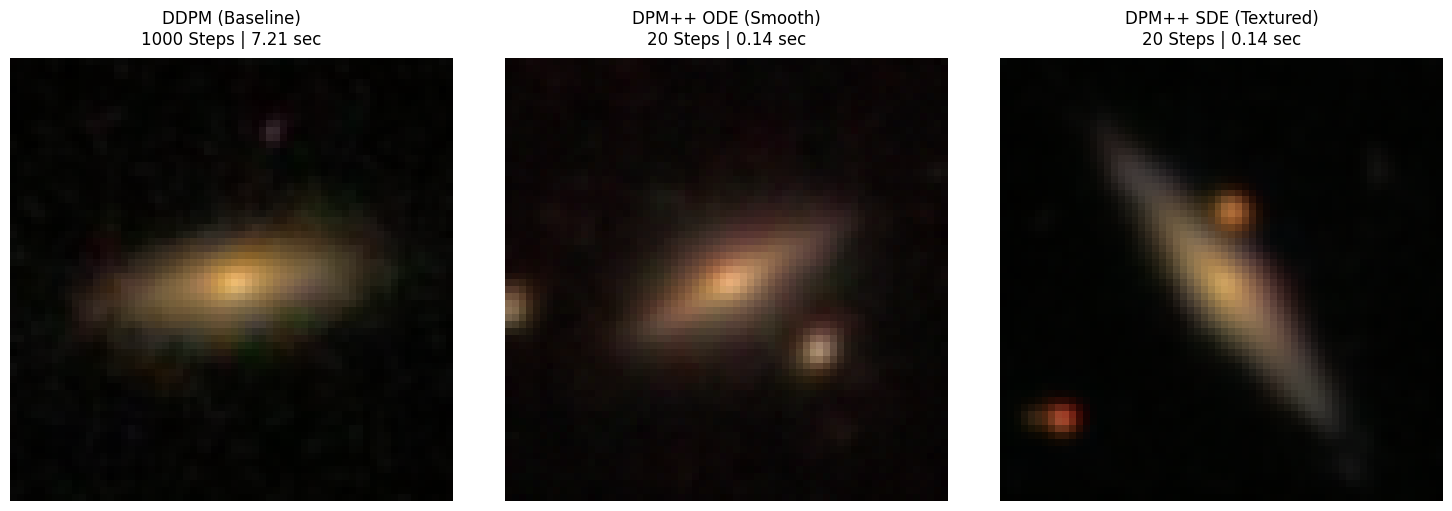

 DPM-Solver++ SDE is 50.2x faster than standard DDPM while maintaining structural texture!


In [21]:
import time
from diffusers import DPMSolverMultistepScheduler, DDPMScheduler

# --- 1. Initialize our Schedulers ---
# Baseline DDPM (SDE, no skipped steps)
baseline_scheduler = DDPMScheduler(
    num_train_timesteps=1000, 
    beta_schedule="linear",
    prediction_type="epsilon"
)

# DPM-Solver++ (ODE, deterministic, fast but can be smooth)
dpm_ode_scheduler = DPMSolverMultistepScheduler(
    num_train_timesteps=1000,
    beta_schedule="linear",
    prediction_type="epsilon",
    solver_order=2,
    algorithm_type="dpmsolver++"
)

# DPM-Solver++ SDE (Stochastic, fast, preserves texture)
dpm_sde_scheduler = DPMSolverMultistepScheduler(
    num_train_timesteps=1000,
    beta_schedule="linear",
    prediction_type="epsilon",
    solver_order=2,
    algorithm_type="sde-dpmsolver++" # This activates the SDE math!
)

# --- 2. Universal Sampling Function ---
def sample_with_scheduler(scheduler, num_steps, target_class_idx, seed=42):
    """Generates an image using a specific scheduler and step count."""
    
    # Configure the scheduler to skip steps
    scheduler.set_timesteps(num_steps)
    
    # Ensure we start with the EXACT SAME NOISE for a fair comparison
    torch.manual_seed(seed)
    x = torch.randn(1, 3, 64, 64).to(device)
    labels = torch.tensor([target_class_idx], dtype=torch.long, device=device)
    
    start_time = time.time()
    
    for t in scheduler.timesteps:
        with torch.no_grad():
            model_output = model(x, t, class_labels=labels).sample
        x = scheduler.step(model_output, t, x).prev_sample
        
    elapsed_time = time.time() - start_time
    
    x = (x + 1) / 2 
    return x[0].cpu().permute(1, 2, 0).numpy(), elapsed_time

# --- 3. Run the Comparison ---
# Class 4 Disk, Edge-on, Rounded Bulge
target_class = 4
fixed_seed = 1024 

print("Running baseline DDPM (1000 steps)...")
img_ddpm, time_ddpm = sample_with_scheduler(baseline_scheduler, num_steps=1000, target_class_idx=target_class, seed=fixed_seed)

print("Running DPM-Solver++ ODE (20 steps)...")
img_ode, time_ode = sample_with_scheduler(dpm_ode_scheduler, num_steps=20, target_class_idx=target_class, seed=fixed_seed)

print("Running DPM-Solver++ SDE (20 steps)...")
img_sde, time_sde = sample_with_scheduler(dpm_sde_scheduler, num_steps=20, target_class_idx=target_class, seed=fixed_seed)

# --- 4. Plotting the Results Side-by-Side ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def plot_result(ax, img, time_taken, title, steps):
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title(f"{title}\n{steps} Steps | {time_taken:.2f} sec", fontsize=12, pad=10)
    ax.axis('off')

plot_result(axes[0], img_ddpm, time_ddpm, "DDPM (Baseline)", 1000)
plot_result(axes[1], img_ode, time_ode, "DPM++ ODE (Smooth)", 20)
plot_result(axes[2], img_sde, time_sde, "DPM++ SDE (Textured)", 20)

plt.tight_layout()
plt.show()

# Print Speedup
speedup = time_ddpm / time_sde
print(f" DPM-Solver++ SDE is {speedup:.1f}x faster than standard DDPM while maintaining structural texture!")

### Quantifying Generative Quality: Fréchet Inception Distance (FID)

While our synthetic galaxies might look highly realistic to the human eye, visual inspection is subjective. To strictly evaluate a generative model, we need a robust mathematical metric that proves our generated data shares the same physical and structural distribution as the real universe.

For generative models, standard metrics like Mean Squared Error (MSE) fail. If our model generates a physically perfect spiral galaxy, but it is rotated by 10 degrees or shifted 5 pixels to the left compared to the target image, MSE will report a massive error. We don't want pixel-to-pixel matching; we want distributional similarity.

To measure this, the industry standard is the Fréchet Inception Distance (FID).


#### <span style="color:orange">*pip install torchmetrics torch-fidelity*</font>


#### How FID Works

FID evaluates the quality of generated images by comparing their deep, structural features against real images, mimicking human visual perception.

1. Feature Extraction: We pass both our real Galaxy10 dataset and our newly generated DDPM galaxies through a pre-trained image classification network (specifically, Inception-v3). We do not look at the final classification labels. Instead, we extract the activations from a deep, intermediate pooling layer. This layer captures high-level features like spiral arms, central bulges, edges, and textures.

2. Statistical Modeling: We assume these extracted feature vectors follow a continuous multivariate Gaussian distribution. We calculate the mean ($\mu$) and the covariance matrix ($\Sigma$) for both the real feature distribution and the generated (fake) feature distribution.

3. Calculating the Distance: We compute the Fréchet distance (also known as the Wasserstein-2 distance) between these two multivariate Gaussians.

#### The Mathematical Formulation

The FID score is calculated using the means ($\mu_r, \mu_g$) and covariance matrices ($\Sigma_r, \Sigma_g$) of the real ($r$) and generated ($g$) image features:
$$FID = ||\mu_r - \mu_g||^2 + \text{Tr}\left(\Sigma_r + \Sigma_g - 2(\Sigma_r \Sigma_g)^{1/2}\right)$$
$||\mu_r - \mu_g||^2$: The squared Euclidean distance between the feature means. This penalizes the model if the "average" generated galaxy looks fundamentally different from the "average" real galaxy.

$\text{Tr}(...)$: The trace of the covariance matrices. This penalizes the model if the generated galaxies lack diversity (e.g., if it only generates one exact type of spiral galaxy over and over, known as mode collapse).

#### Interpreting the Score

Lower is better. An FID of $0.0$ indicates that the generated distribution is statistically identical to the real distribution.

Because FID is highly sensitive to noise, blur, and structural artifacts, it is the perfect metric to prove that our DDPM has truly learned the underlying physics and morphology of the Galaxy10 dataset.

Initializing FID Metric (Feature=64)...
Fetching real image batches...
Generating FAKE galaxies using DPM-Solver++ (20 steps)...

Calculating FID Scores...

⏱️ Generation took 2.31 seconds
🟢 IDEAL (Real vs. Real):   0.02
🔵 DDPM (Real vs. Fake):    0.31
🔴 WORST (Real vs. Noise): 450.19


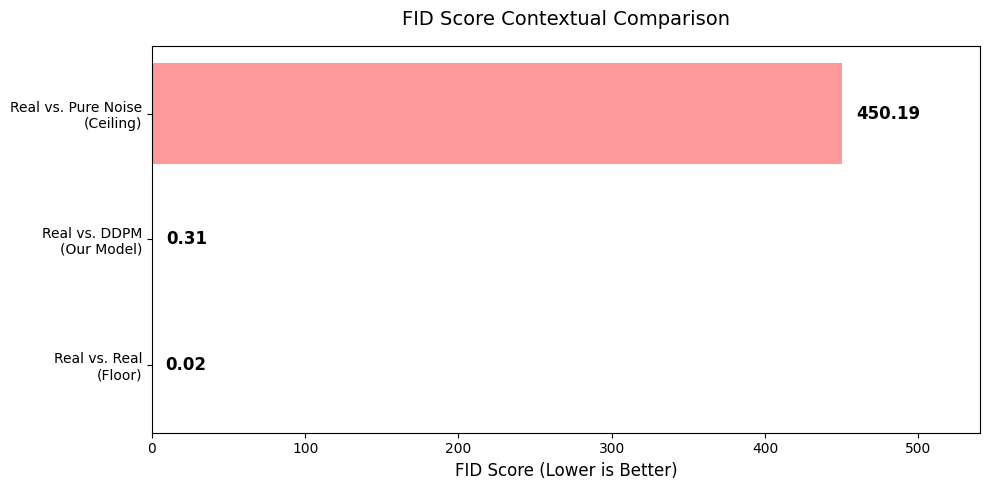

In [22]:
import torch
from torchmetrics.image.fid import FrechetInceptionDistance
import time
import matplotlib.pyplot as plt
import numpy as np

print("Initializing FID Metric (Feature=64)...")
fid = FrechetInceptionDistance(feature=64, normalize=False).to(device)

def compute_fid(img_batch_1, img_batch_2):
    """Helper function to reset, update, and compute FID for two batches."""
    fid.reset()
    # Convert from [-1, 1] floats to [0, 255] uint8 bytes
    b1_uint8 = ((img_batch_1 + 1) / 2 * 255).clamp(0, 255).byte()
    b2_uint8 = ((img_batch_2 + 1) / 2 * 255).clamp(0, 255).byte()
    
    fid.update(b1_uint8, real=True)
    fid.update(b2_uint8, real=False)
    return fid.compute().item()

# --- 1. Get Data Baselines ---
print("Fetching real image batches...")
real_batch_1, labels_1 = next(iter(dataloader))
real_batch_2, _ = next(iter(dataloader))

real_batch_1 = real_batch_1.to(device)
real_batch_2 = real_batch_2.to(device)
labels_1 = labels_1.to(device, dtype=torch.long)

# --- 2. Generate Fake Data ---
print("Generating FAKE galaxies using DPM-Solver++ (20 steps)...")
model.eval()
fake_noise = torch.randn_like(real_batch_1)
dpm_scheduler.set_timesteps(20)

start_time = time.time()
for t in dpm_scheduler.timesteps:
    with torch.no_grad():
        model_output = model(fake_noise, t, class_labels=labels_1).sample
    fake_noise = dpm_scheduler.step(model_output, t, fake_noise).prev_sample
calc_time = time.time() - start_time

fake_batch = fake_noise
pure_noise_batch = torch.randn_like(real_batch_1)

# --- 3. Compute Comparisons ---
print("\nCalculating FID Scores...")
score_real_vs_real = compute_fid(real_batch_1, real_batch_2)     # The Floor
score_real_vs_fake = compute_fid(real_batch_1, fake_batch)       # Our Model
score_real_vs_noise = compute_fid(real_batch_1, pure_noise_batch) # The Ceiling

print(f"\n⏱️ Generation took {calc_time:.2f} seconds")
print(f"🟢 IDEAL (Real vs. Real):   {score_real_vs_real:.2f}")
print(f"🔵 DDPM (Real vs. Fake):    {score_real_vs_fake:.2f}")
print(f"🔴 WORST (Real vs. Noise): {score_real_vs_noise:.2f}")

# --- 4. Plotting for Presentation ---
scores = [score_real_vs_noise, score_real_vs_fake, score_real_vs_real]
labels = ['Real vs. Pure Noise\n(Ceiling)', 'Real vs. DDPM\n(Our Model)', 'Real vs. Real\n(Floor)']
colors = ['#ff9999', '#66b3ff', '#99ff99']

plt.figure(figsize=(10, 5))
bars = plt.barh(labels, scores, color=colors)
plt.xlabel('FID Score (Lower is Better)', fontsize=12)
plt.title('FID Score Contextual Comparison', fontsize=14, pad=15)

# Add text labels directly on the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + (max(scores)*0.02), bar.get_y() + bar.get_height()/2, 
             f'{width:.2f}', va='center', fontsize=12, fontweight='bold')

plt.xlim(0, max(scores) * 1.2) # Give room for the text labels
plt.gca().invert_yaxis() # Put the worst score at the bottom
plt.tight_layout()
plt.show()

#### Computing Cross-Category FID

Initializing FID Metric (Feature=64)...
Gathering pure batches of specific classes...
Generating FAKE galaxies for Class 7...

Calculating Cross-Class FID Scores...

⏱️ Generation took 4.40 seconds
🟢 IN-CLASS (Fake 7 vs. Real 7):   0.92
🔴 CROSS-CLASS (Fake 7 vs. Real 4):   1.23


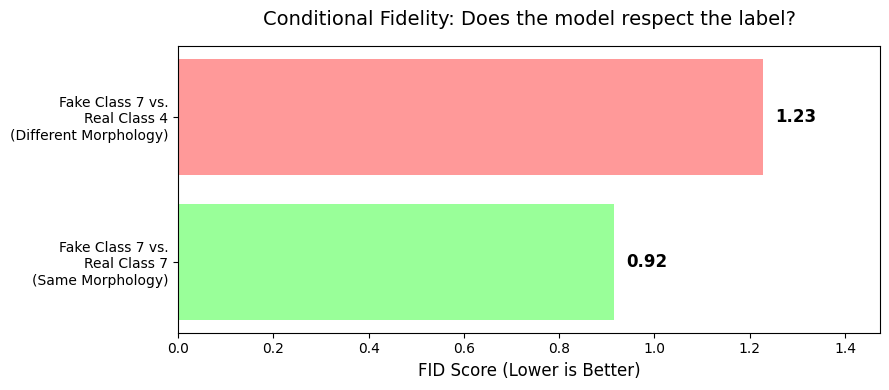

In [23]:
import torch
from torchmetrics.image.fid import FrechetInceptionDistance
import time
import matplotlib.pyplot as plt
import numpy as np

print("Initializing FID Metric (Feature=64)...")
fid = FrechetInceptionDistance(feature=64, normalize=False).to(device)

def compute_fid(img_batch_1, img_batch_2):
    """Helper function to reset, update, and compute FID for two batches."""
    fid.reset()
    b1_uint8 = ((img_batch_1 + 1) / 2 * 255).clamp(0, 255).byte()
    b2_uint8 = ((img_batch_2 + 1) / 2 * 255).clamp(0, 255).byte()
    
    fid.update(b1_uint8, real=True)
    fid.update(b2_uint8, real=False)
    return fid.compute().item()

# --- 1. Helper Function: Gather pure batches of one class ---
def get_real_batch_of_class(target_class, num_samples=64):
    """Scans the dataset to build a batch entirely of one class."""
    images = []
    # We iterate over the base dataset to extract specific labels
    for img, label in dataset: 
        if label == target_class:
            images.append(img)
        if len(images) == num_samples:
            break
    return torch.stack(images).to(device)

print("Gathering pure batches of specific classes...")
# Let's test Class 4 (Edge-on Disk) vs. Class 7 (Face-on Tight Spiral)
class_A = 7 
class_B = 4
batch_size = 128

real_class_A = get_real_batch_of_class(class_A, batch_size)
real_class_B = get_real_batch_of_class(class_B, batch_size)

# --- 2. Generate Fake Data for Class A ---
print(f"Generating FAKE galaxies for Class {class_A}...")
model.eval()
fake_noise = torch.randn_like(real_class_A)

# Force the model to generate only Class A
labels_A = torch.tensor([class_A] * batch_size, dtype=torch.long, device=device)

dpm_scheduler.set_timesteps(20)
start_time = time.time()
for t in dpm_scheduler.timesteps:
    with torch.no_grad():
        model_output = model(fake_noise, t, class_labels=labels_A).sample
    fake_noise = dpm_scheduler.step(model_output, t, fake_noise).prev_sample
calc_time = time.time() - start_time

fake_class_A = fake_noise

# --- 3. Compute Comparisons ---
print("\nCalculating Cross-Class FID Scores...")

# 1. Fake A vs Real A (Should be a strong match / low score)
score_same_class = compute_fid(fake_class_A, real_class_A)

# 2. Fake A vs Real B (Should be a poor match / high score)
score_diff_class = compute_fid(fake_class_A, real_class_B)

print(f"\n⏱️ Generation took {calc_time:.2f} seconds")
print(f"🟢 IN-CLASS (Fake {class_A} vs. Real {class_A}):   {score_same_class:.2f}")
print(f"🔴 CROSS-CLASS (Fake {class_A} vs. Real {class_B}):   {score_diff_class:.2f}")

# --- 4. Plotting for Presentation ---
scores = [score_diff_class, score_same_class]
labels = [f'Fake Class {class_A} vs.\nReal Class {class_B}\n(Different Morphology)', 
          f'Fake Class {class_A} vs.\nReal Class {class_A}\n(Same Morphology)']
colors = ['#ff9999', '#99ff99']

plt.figure(figsize=(9, 4))
bars = plt.barh(labels, scores, color=colors)
plt.xlabel('FID Score (Lower is Better)', fontsize=12)
plt.title('Conditional Fidelity: Does the model respect the label?', fontsize=14, pad=15)

# Add text labels directly on the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + (max(scores)*0.02), bar.get_y() + bar.get_height()/2, 
             f'{width:.2f}', va='center', fontsize=12, fontweight='bold')

plt.xlim(0, max(scores) * 1.2) # Give room for the text labels
plt.gca().invert_yaxis() # Put the worst score at the bottom
plt.tight_layout()
plt.show()